# Coding Practice \#3: Due October 24th at midnight in Canvas

All files needed are located in the 'cp3_data_f25.zip' file.

Answer the questions below in a Jupyter notebook. You can modify this notebook by adding cells with your answers.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import re
import geopandas as gpd
os.chdir("C:/Users/messy/Desktop/School/ECON570") #Windows path
# os.chdir("/Users/jackson/Documents/ECON570") #Mac path

## Exercise 0: Kaiman, Jackson
Replace 'Last, First' above with your actual name. Enter it as your last name, first name.

## Exercise 1: Cleaning and merging panel data from multiple sources 

Economists often use data from multiple sources to conduct their analysis. It is almost never the case that all the data required for a project is available from one source. This is an artifact of how economic data are collected in the United States. For example, the Bureau of Labor Statistics (BLS) is responsible for measuring the unemployment rate, while the Bureau of Economic Analysis (BEA) is responsible for measuring gross domestic product. (These bureaus are themselves parts of different departments of the executive branch&mdash;the Department of Labor in the case of the BLS and the Department of Commerce in the case of the BEA.) As a result, data are often published in different formats that require some extra work to merge.

In this exercise, your task is to merge state-level unemployment rate data from the BLS with state-level GDP data from the BEA.  You will then make a scatterplot showing [Okun's Law](https://en.wikipedia.org/wiki/Okun%27s_law) for Ohio and Alabama.

**Note:** An easier way to do this is to use the FRED API to retrieve each series directly. However, the purpose of this exercise is to practice cleaning and merging data, so let's get to it.

### Part (a): Importing and cleaning the GDP data
1. Read in the file "state_gdp.csv" as a pandas data frame called `gdp`. This file (downloaded from https://apps.bea.gov/regional/Downloadzip.cfm) contains annualized real GDP (in millions of chained 2009 dollars) for each quarter from 2005Q1 to 2018Q1 for each state and industry. Note that the data is in "wide" format.
2. The data contain a breakdown of each industry's contribution to GDP in each state. For this exercise, we are only interested in *total* real GDP for each state. Thus, keep only the rows for which the column "Description" is equal to "All industry total".


In [2]:
state = pd.read_csv('data\state_gdp.csv')
state.head()

,GeoFIPS,GeoName,Region,ComponentId,ComponentName,IndustryId,IndustryClassification,Description,2005:Q1,2005:Q2,...,2015:Q4,2016:Q1,2016:Q2,2016:Q3,2016:Q4,2017:Q1,2017:Q2,2017:Q3,2017:Q4,2018:Q1
0,"""00000""",United States,,900.0,Real GDP by state (millions of chained 2009 do...,1.0,...,All industry total,14062401,14166189,...,16218296,16255446,16332470,16440377,16506954,16543079,16653363,16789458,16900097,16977710
1,"""00000""",United States,,900.0,Real GDP by state (millions of chained 2009 do...,2.0,...,Private industries,12173573,12277937,...,14265624,14298140,14370311,14470439,14539586,14578572,14691989,14828362,14940434,15021222
2,"""00000""",United States,,900.0,Real GDP by state (millions of chained 2009 do...,3.0,11,"Agriculture, forestry, fishing, and hunting",123808,128165,...,157524,165964,171182,171361,169982,157602,153243,152298,151649,149871
3,"""00000""",United States,,900.0,Real GDP by state (millions of chained 2009 do...,6.0,21,"Mining, quarrying, and oil and gas extraction",220173,221294,...,370495,363295,335000,330474,337286,347078,369629,378294,387430,392613
4,"""00000""",United States,,900.0,Real GDP by state (millions of chained 2009 do...,10.0,22,Utilities,249585,242868,...,263545,268402,270346,279668,280531,275956,281843,277451,283387,278725


In [3]:
state.columns

Index(['GeoFIPS', 'GeoName', 'Region', 'ComponentId', 'ComponentName',
       'IndustryId', 'IndustryClassification', 'Description', '2005:Q1',
       '2005:Q2', '2005:Q3', '2005:Q4', '2006:Q1', '2006:Q2', '2006:Q3',
       '2006:Q4', '2007:Q1', '2007:Q2', '2007:Q3', '2007:Q4', '2008:Q1',
       '2008:Q2', '2008:Q3', '2008:Q4', '2009:Q1', '2009:Q2', '2009:Q3',
       '2009:Q4', '2010:Q1', '2010:Q2', '2010:Q3', '2010:Q4', '2011:Q1',
       '2011:Q2', '2011:Q3', '2011:Q4', '2012:Q1', '2012:Q2', '2012:Q3',
       '2012:Q4', '2013:Q1', '2013:Q2', '2013:Q3', '2013:Q4', '2014:Q1',
       '2014:Q2', '2014:Q3', '2014:Q4', '2015:Q1', '2015:Q2', '2015:Q3',
       '2015:Q4', '2016:Q1', '2016:Q2', '2016:Q3', '2016:Q4', '2017:Q1',
       '2017:Q2', '2017:Q3', '2017:Q4', '2018:Q1'],
      dtype='object')

3. The data contains real GDP for the United States as a whole as well as for several subregions. We are only interested in states so we will drop the others. To do this, drop any row for which the column 'GeoName' contains "United States", "New England", "Mideast", "Great Lakes", "Plains", "Southeast", "Southwest", "Rocky Mountain", or "Far West".


In [4]:
drop_list = [
    "United States", "New England", "Mideast", "Great Lakes",
    "Plains", "Southeast", "Southwest", "Rocky Mountain", "Far West"]

state = state[~state['GeoName'].isin(drop_list)]
state

,GeoFIPS,GeoName,Region,ComponentId,ComponentName,IndustryId,IndustryClassification,Description,2005:Q1,2005:Q2,...,2015:Q4,2016:Q1,2016:Q2,2016:Q3,2016:Q4,2017:Q1,2017:Q2,2017:Q3,2017:Q4,2018:Q1
24,"""01000""",Alabama,5,900.0,Real GDP by state (millions of chained 2009 do...,1.0,...,All industry total,169741,172087,...,178970,179900,180799,180480,181251,182336,182433,182673,183928,184492
25,"""01000""",Alabama,5,900.0,Real GDP by state (millions of chained 2009 do...,2.0,...,Private industries,140738,143080,...,149425,150317,151118,150786,151398,152377,152477,153449,154656,155240
26,"""01000""",Alabama,5,900.0,Real GDP by state (millions of chained 2009 do...,3.0,11,"Agriculture, forestry, fishing, and hunting",2573,2625,...,2274,2342,2339,2167,2083,2349,2169,2078,2090,2064
27,"""01000""",Alabama,5,900.0,Real GDP by state (millions of chained 2009 do...,6.0,21,"Mining, quarrying, and oil and gas extraction",3277,3343,...,2944,2558,2243,2253,2331,2824,3297,3372,3468,3497
28,"""01000""",Alabama,5,900.0,Real GDP by state (millions of chained 2009 do...,10.0,22,Utilities,4601,4743,...,5091,4989,5259,5630,5225,5057,4645,5409,5507,5383
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1246,"""56000""",Wyoming,7,900.0,Real GDP by state (millions of chained 2009 do...,81.0,81,Other services (except government and gover...,555,543,...,517,518,524,492,496,500,501,510,512,504
1247,"""56000""",Wyoming,7,900.0,Real GDP by state (millions of chained 2009 do...,82.0,...,Government and government enterprises,4427,4329,...,5327,5445,5368,5315,5274,5265,5265,5217,5188,5149
1440,Note: See the included footnote file.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1441,"Last updated: July 24, 2018 -- new statistics ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


4a. Drop the columns 'GeoFIPS', 'Region', 'ComponentId', 'ComponentName', 'IndustryId', 'IndustryClassification', and 'Description'.

4b. Rename the column 'GeoName' to 'state'.


In [5]:
state.columns

Index(['GeoFIPS', 'GeoName', 'Region', 'ComponentId', 'ComponentName',
       'IndustryId', 'IndustryClassification', 'Description', '2005:Q1',
       '2005:Q2', '2005:Q3', '2005:Q4', '2006:Q1', '2006:Q2', '2006:Q3',
       '2006:Q4', '2007:Q1', '2007:Q2', '2007:Q3', '2007:Q4', '2008:Q1',
       '2008:Q2', '2008:Q3', '2008:Q4', '2009:Q1', '2009:Q2', '2009:Q3',
       '2009:Q4', '2010:Q1', '2010:Q2', '2010:Q3', '2010:Q4', '2011:Q1',
       '2011:Q2', '2011:Q3', '2011:Q4', '2012:Q1', '2012:Q2', '2012:Q3',
       '2012:Q4', '2013:Q1', '2013:Q2', '2013:Q3', '2013:Q4', '2014:Q1',
       '2014:Q2', '2014:Q3', '2014:Q4', '2015:Q1', '2015:Q2', '2015:Q3',
       '2015:Q4', '2016:Q1', '2016:Q2', '2016:Q3', '2016:Q4', '2017:Q1',
       '2017:Q2', '2017:Q3', '2017:Q4', '2018:Q1'],
      dtype='object')

In [6]:
drop_cols = ['GeoFIPS', 'Region', 'IndustryId', 'ComponentId', 'ComponentName', 'IndustryClassification', 'Description']
state = state.drop(columns=drop_cols)
state.head()


,GeoName,2005:Q1,2005:Q2,2005:Q3,2005:Q4,2006:Q1,2006:Q2,2006:Q3,2006:Q4,2007:Q1,...,2015:Q4,2016:Q1,2016:Q2,2016:Q3,2016:Q4,2017:Q1,2017:Q2,2017:Q3,2017:Q4,2018:Q1
24,Alabama,169741,172087,171819,173245,173722.0,174750.0,175038.0,175191.0,173546,...,178970,179900,180799,180480,181251,182336,182433,182673,183928,184492
25,Alabama,140738,143080,142843,144070,144943.0,145416.0,146197.0,145472.0,143485,...,149425,150317,151118,150786,151398,152377,152477,153449,154656,155240
26,Alabama,2573,2625,2614,2662,2072.0,2397.0,2262.0,2049.0,1641,...,2274,2342,2339,2167,2083,2349,2169,2078,2090,2064
27,Alabama,3277,3343,2985,2944,3102.0,2853.0,2934.0,3111.0,3292,...,2944,2558,2243,2253,2331,2824,3297,3372,3468,3497
28,Alabama,4601,4743,5025,4833,4982.0,5065.0,5282.0,4971.0,4998,...,5091,4989,5259,5630,5225,5057,4645,5409,5507,5383


In [7]:
state.rename(columns={'State':'state', 'variable':'date', 'value': 'real_gdp'}, inplace=True) #remove capital S
state.head(5)


,GeoName,2005:Q1,2005:Q2,2005:Q3,2005:Q4,2006:Q1,2006:Q2,2006:Q3,2006:Q4,2007:Q1,...,2015:Q4,2016:Q1,2016:Q2,2016:Q3,2016:Q4,2017:Q1,2017:Q2,2017:Q3,2017:Q4,2018:Q1
24,Alabama,169741,172087,171819,173245,173722.0,174750.0,175038.0,175191.0,173546,...,178970,179900,180799,180480,181251,182336,182433,182673,183928,184492
25,Alabama,140738,143080,142843,144070,144943.0,145416.0,146197.0,145472.0,143485,...,149425,150317,151118,150786,151398,152377,152477,153449,154656,155240
26,Alabama,2573,2625,2614,2662,2072.0,2397.0,2262.0,2049.0,1641,...,2274,2342,2339,2167,2083,2349,2169,2078,2090,2064
27,Alabama,3277,3343,2985,2944,3102.0,2853.0,2934.0,3111.0,3292,...,2944,2558,2243,2253,2331,2824,3297,3372,3468,3497
28,Alabama,4601,4743,5025,4833,4982.0,5065.0,5282.0,4971.0,4998,...,5091,4989,5259,5630,5225,5057,4645,5409,5507,5383


5a. Convert the data from wide to long format. The rows should be `(state, date)` and the column should be `real_gdp`. 

5b. Reset the index. Rename the columns `variable` to `date` and `value` to `real_gdp`. 

5c. Convert 'real_gdp' to a floating point number (the columns containing the GDP data were originally imported as strings since some values of GDP for some industries/states are censored or missing).

In [8]:
q_cols = [c for c in state.columns if re.fullmatch(r"\d{4}:Q[1-4]", str(c))]

gdp_long = state.melt(
    id_vars=["GeoName"],
    value_vars=q_cols,
    var_name="quarter",
    value_name="real_gdp"
)
gdp_long = gdp_long.rename(columns={"GeoName": "state"})
gdp_long["date"] = (
    gdp_long["quarter"]
    .str.replace(":", "", regex=False)
    .pipe(lambda s: pd.PeriodIndex(s, freq="Q-DEC").to_timestamp(how="start"))
)
gdp_long["real_gdp"] = pd.to_numeric(gdp_long["real_gdp"], errors="coerce")



6. Finally, we should convert the date to a datetime object. Unfortunately, the `datetime` package doesn't like the format of our dates: "2005:Q1" etc. This will require a few steps:

    1. Use the `.str.replace()` method to replace ":Q" with a dash "-q".
    2. Convert 'date' to a datetime object as normal. 

In [9]:
gdp_clean = (gdp_long.groupby(['state','date'], as_index=False)['real_gdp'].sum()
               .sort_values(['state','date'])
               .reset_index(drop=True))
gdp_clean.head()

,state,date,real_gdp
0,Alabama,2005-01-01,508692.0
1,Alabama,2005-04-01,515934.0
2,Alabama,2005-07-01,515024.0
3,Alabama,2005-10-01,520067.0
4,Alabama,2006-01-01,522280.0


Done above^

### Part (b): Importing and cleaning the unemployment rate data

1. Import the file "state_unemp.xlsx" as a Pandas data frame called `unemp`.  This file (downloaded from https://www.bls.gov/lau/rdscnp16.htm) contains measures of the population, labor force, employment, unemployment, and unemployment rate by state (plus New York City and Los Angeles County) in each month from January 1976 to September 2018. Notice how different the formating is compared to the GDP data! When importing, do the following:

    1. The column names are not friendly for importing, so keep only columns 1, 2, 3, and 10. Try the `usecols` option in `read_excel`. 
    2. Use `skiprows=7` to avoid importing the messy headers.
    2. Set the column names to 'state', 'year', 'month', and 'unemp_rate'. 


In [10]:
unemp= pd.read_excel("data\state_unemp.xlsx", skiprows = 7, usecols=  [1,2,3,10])
unemp.columns = ['state', 'year', 'month', 'unemp_rate']

unemp

,state,year,month,unemp_rate
0,Alabama,1976,1,6.7
1,Alaska,1976,1,7.1
2,Arizona,1976,1,10.3
3,Arkansas,1976,1,7.4
4,California,1976,1,9.1
...,...,...,...,...
27184,Virginia,2018,9,2.9
27185,Washington,2018,9,4.4
27186,West Virginia,2018,9,5.2
27187,Wisconsin,2018,9,3.0


2. Drop the observations where state is either "Los Angeles County" or "New York City".

In [11]:
unemp = unemp[~unemp['state'].isin(['New York City', 'Los Angeles County'])]
unemp

,state,year,month,unemp_rate
0,Alabama,1976,1,6.7
1,Alaska,1976,1,7.1
2,Arizona,1976,1,10.3
3,Arkansas,1976,1,7.4
4,California,1976,1,9.1
...,...,...,...,...
27184,Virginia,2018,9,2.9
27185,Washington,2018,9,4.4
27186,West Virginia,2018,9,5.2
27187,Wisconsin,2018,9,3.0


In [12]:
print(unemp.columns.tolist())


['state', 'year', 'month', 'unemp_rate']


3. Next, we need to create a date variable that we can use to merge with the gdp data. The gdp data are quarterly. 

   1. Create a column that is 'yyyy-mm' constructed from the year and month columns.  
   2. Convert your string date variable to a datetime. Name your datetime variable `date`.
   3. Drop the year and month columns.

In [13]:
unemp['yyyy-mm'] = unemp['year'].astype(str) + '-' + unemp['month'].astype(str).str.zfill(2)
unemp['date'] = pd.to_datetime(unemp['yyyy-mm'], format='%Y-%m')
unemp = unemp.drop(columns=['year', 'month', 'yyyy-mm'])
unemp = unemp.sort_values(['state', 'date']).reset_index(drop=True)
unemp.head()

C:\Users\messy\AppData\Local\Temp\ipykernel_41908\2960938984.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unemp['yyyy-mm'] = unemp['year'].astype(str) + '-' + unemp['month'].astype(str).str.zfill(2)
C:\Users\messy\AppData\Local\Temp\ipykernel_41908\2960938984.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unemp['date'] = pd.to_datetime(unemp['yyyy-mm'], format='%Y-%m')


,state,unemp_rate,date
0,Alabama,6.7,1976-01-01
1,Alabama,6.7,1976-02-01
2,Alabama,6.6,1976-03-01
3,Alabama,6.5,1976-04-01
4,Alabama,6.4,1976-05-01


4. Now we need to turn the monthly data into quarterly data. This is a little more complicated because we need to do this for each state. We are combining a groupby and a resample. 
     1. Set the index to `date`. We need a datetime index in order to resample.
     2. Groupby `state` and use `.resample('QS').mean()`
     
*We are grouping by state. Then, within each group, we are resampling, and taking the mean over the 3 months in each quarter. The 'QS' tells pandas to assign the first day of the quarter ('S' for start) as the date, e.g., 1999-04-01 for the second quarter.*

In [14]:

unemp_q = (
    unemp
    .set_index('date')
    .groupby('state')['unemp_rate']
    .resample('QS')
    .mean()
    .reset_index()
    .sort_values(['state','date'])
    .reset_index(drop=True))

unemp_q.head()

,state,date,unemp_rate
0,Alabama,1976-01-01,6.666667
1,Alabama,1976-04-01,6.466667
2,Alabama,1976-07-01,6.766667
3,Alabama,1976-10-01,7.166667
4,Alabama,1977-01-01,7.666667


In [15]:
unemp_q.set_index('date', inplace=True)
unemp_q.head()

,state,unemp_rate
date,,
1976-01-01,Alabama,6.666667
1976-04-01,Alabama,6.466667
1976-07-01,Alabama,6.766667
1976-10-01,Alabama,7.166667
1977-01-01,Alabama,7.666667


In [16]:
unemp.dtypes

state                 object
unemp_rate           float64
date          datetime64[ns]
dtype: object

### Part (c): Merging and plotting the data

Wow, that was a lot of work. Bending data to our will takes careful effort. 

At this point, we have two data sets. In each dataset, the unit of observation is a state-quarter. 

1. Create a new data frame by merging the gdp and unemployment rate data on 'state' and 'date'. Set 'state' and 'date' as the index on the new data frame and sort the index. Use an inner merge. 

In [17]:
merged = (
    pd.merge(gdp_clean, unemp_q, on=['state', 'date'], how='inner')
      .set_index(['state', 'date'])
      .sort_index()
)
merged

real_gdp  unemp_rate
state   date                            
Alabama 2005-01-01  508692.0    4.933333
        2005-04-01  515934.0    4.500000
        2005-07-01  515024.0    4.333333
        2005-10-01  520067.0    4.233333
        2006-01-01  522280.0    4.100000
...                      ...         ...
Wyoming 2017-01-01  100160.0    4.500000
        2017-04-01  104533.0    4.033333
        2017-07-01  104115.0    4.066667
        2017-10-01  104635.0    4.166667
        2018-01-01  105491.0    4.000000

[2703 rows x 2 columns]

2. Okun's Law is about changes in gdp and unemployment. 

    1. Compute the percent change in real gdp for each state and quarter.
    2. Compute the difference in the unemployment rate for each state and quarter.

Notice that we are taking the growth rate of gdp, but the difference of unemployment. This is because it is awkward to talk about the percent change of variables that are already in percentage terms. 

In [18]:
merged['gdp_growth'] = (
    merged.groupby('state')['real_gdp']
          .pct_change() * 100 
)
merged['unemp_diff'] = (
    merged.groupby('state')['unemp_rate']
          .diff()
)
merged = merged.dropna(subset=['gdp_growth', 'unemp_diff'])
merged

real_gdp  unemp_rate  gdp_growth  unemp_diff
state   date                                                    
Alabama 2005-04-01  515934.0    4.500000    1.423651   -0.433333
        2005-07-01  515024.0    4.333333   -0.176379   -0.166667
        2005-10-01  520067.0    4.233333    0.979178   -0.100000
        2006-01-01  522280.0    4.100000    0.425522   -0.133333
        2006-04-01  524959.0    4.100000    0.512943    0.000000
...                      ...         ...         ...         ...
Wyoming 2017-01-01  100160.0    4.500000    0.797037   -0.466667
        2017-04-01  104533.0    4.033333    4.366014   -0.466667
        2017-07-01  104115.0    4.066667   -0.399874    0.033333
        2017-10-01  104635.0    4.166667    0.499448    0.100000
        2018-01-01  105491.0    4.000000    0.818082   -0.166667

[2652 rows x 4 columns]

3. Change the index to 'state'.

In [19]:
merged.reset_index().set_index(['state'],inplace=True)
merged


real_gdp  unemp_rate  gdp_growth  unemp_diff
state   date                                                    
Alabama 2005-04-01  515934.0    4.500000    1.423651   -0.433333
        2005-07-01  515024.0    4.333333   -0.176379   -0.166667
        2005-10-01  520067.0    4.233333    0.979178   -0.100000
        2006-01-01  522280.0    4.100000    0.425522   -0.133333
        2006-04-01  524959.0    4.100000    0.512943    0.000000
...                      ...         ...         ...         ...
Wyoming 2017-01-01  100160.0    4.500000    0.797037   -0.466667
        2017-04-01  104533.0    4.033333    4.366014   -0.466667
        2017-07-01  104115.0    4.066667   -0.399874    0.033333
        2017-10-01  104635.0    4.166667    0.499448    0.100000
        2018-01-01  105491.0    4.000000    0.818082   -0.166667

[2652 rows x 4 columns]

4. Now we can make the desired scatterplot. Plot the GDP growth rate against the change in the unemployment rate for Ohio and Alabama on the same figure.

    1. Put GDP growth on the vertical axis and the change in the unemployment rate on the horizontal axis. 
    2. Make the markers for Ohio red triangles that aren't filled in and the markers for Alabama purple x's. 
    3. Make other aspects of the plot look nice, including nice labels and a legend.

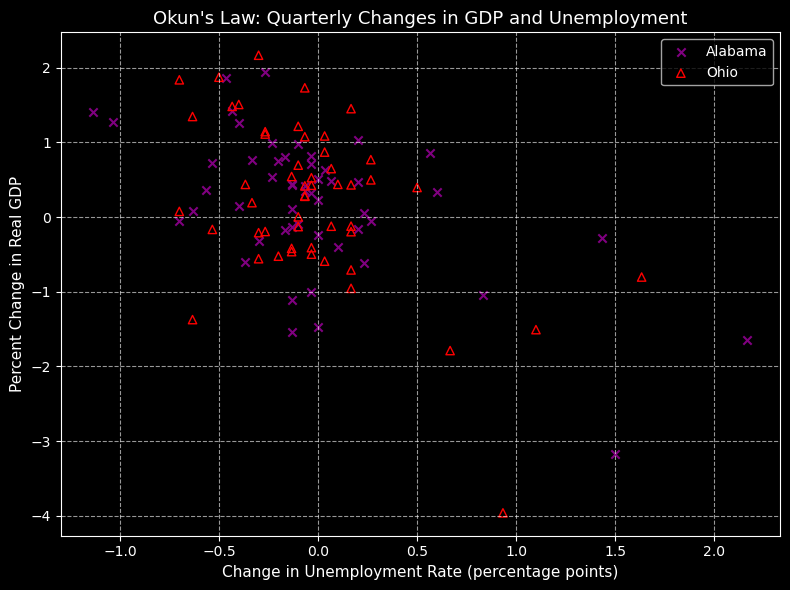

In [20]:
ohio = merged.loc['Ohio']
alabama = merged.loc['Alabama']

plt.figure(figsize=(8,6))

plt.scatter(
    alabama['unemp_diff'], 
    alabama['gdp_growth'],
    color='purple',
    marker='x',
    label='Alabama'
)

plt.scatter(
    ohio['unemp_diff'], 
    ohio['gdp_growth'],
    facecolors='none',    # unfilled
    edgecolors='red',
    marker='^',
    label='Ohio'
)
plt.xlabel('Change in Unemployment Rate (percentage points)', fontsize=11)
plt.ylabel('Percent Change in Real GDP', fontsize=11)
plt.title("Okun's Law: Quarterly Changes in GDP and Unemployment", fontsize=13)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## Exercise 2: Regular expressions

In this exercise, your task is to build a regular expression that extracts 10-digit phone numbers in various formats. Then, we'll standardize the formats.

Run the following code to create the dataframe.

In [21]:
phone_dict= {'info': ['home: (406) 608-1937 \n cell: (406) 334-1868 ',
                     'home: 1 068-293-1048 \n cell: 1 608-345-5678',
                     'home: 1 292-476-3632 \n cell: 1 292-284-2240',
                     'home: 901-004-4000 \n cell: 901-994-4999',
                     'home: 345-575-4499 \n cell: 1 345-777-9090',
                     'home: 6m08-999-9999 \n cell: 6m08-1nj-2867 ',
                     'home: 68-656-7899 \n cell: 68-636-7888',
                     'home: 141-41-4141 \n cell: 141-32-2323',
                     'home: 111-222-333 \n cell: 444-555-666',
                     'home: 171-717-1-7711-1177 \n cell: 171-2',
                     'home: 40.040.4000 \n cell: 40.141.4123'],
             'valid': [1,1,1,1,1,0,0,0,0,0,0]}
phone = pd.DataFrame(phone_dict)
phone

,info,valid
0,home: (406) 608-1937 \n cell: (406) 334-1868,1
1,home: 1 068-293-1048 \n cell: 1 608-345-5678,1
2,home: 1 292-476-3632 \n cell: 1 292-284-2240,1
3,home: 901-004-4000 \n cell: 901-994-4999,1
4,home: 345-575-4499 \n cell: 1 345-777-9090,1
5,home: 6m08-999-9999 \n cell: 6m08-1nj-2867,0
6,home: 68-656-7899 \n cell: 68-636-7888,0
7,home: 141-41-4141 \n cell: 141-32-2323,0
8,home: 111-222-333 \n cell: 444-555-666,0
9,home: 171-717-1-7711-1177 \n cell: 171-2,0


The first column ('info') has text containing both valid and invalid home and cell phone numbers. The second column ('valid') contains an indicator specifying whether or not the format is valid.

1. Build flexible regular expressions that:
    - *Fully* extracts the home and cell numbers separately from 'info' if 'valid' equals 1.
    - Does not extract the home or cell numbers from 'info' if 'valid' equals 0.

Create new columns called 'home' and 'cell' `str.extract()` and verify that your regular expression works properly.

\[Tip: We can use `{n}` to look a string of *exactly n* of the preceding character. For example, `\w{4}` looks for a string of exactly four alphanumeric characters.\]

In [22]:
num_pat = r'(?:1\s+)?(?:\(\d{3}\)\s*\d{3}-\d{4}|\d{3}-\d{3}-\d{4})'
home_pat = rf'home:\s*({num_pat})'
cell_pat = rf'cell:\s*({num_pat})'

phone['home'] = phone['info'].str.extract(home_pat, flags=re.I)
phone['cell'] = phone['info'].str.extract(cell_pat, flags=re.I)

phone

,info,valid,home,cell
0,home: (406) 608-1937 \n cell: (406) 334-1868,1,(406) 608-1937,(406) 334-1868
1,home: 1 068-293-1048 \n cell: 1 608-345-5678,1,1 068-293-1048,1 608-345-5678
2,home: 1 292-476-3632 \n cell: 1 292-284-2240,1,1 292-476-3632,1 292-284-2240
3,home: 901-004-4000 \n cell: 901-994-4999,1,901-004-4000,901-994-4999
4,home: 345-575-4499 \n cell: 1 345-777-9090,1,345-575-4499,1 345-777-9090
5,home: 6m08-999-9999 \n cell: 6m08-1nj-2867,0,NaN,NaN
6,home: 68-656-7899 \n cell: 68-636-7888,0,NaN,NaN
7,home: 141-41-4141 \n cell: 141-32-2323,0,NaN,NaN
8,home: 111-222-333 \n cell: 444-555-666,0,NaN,NaN
9,home: 171-717-1-7711-1177 \n cell: 171-2,0,NaN,NaN


2. Create two more columns of your dataframe called 'home_formatted' and 'cell_formatted' that converts all valid home and cell phone numbers to the following standard format: `XXX-XXX-XXXX'.

In [23]:
def standardize(num):
    if pd.isna(num):
        return pd.NA
    digits = re.sub(r'\D', '', str(num))    
    if len(digits) == 11 and digits.startswith('1'):
        digits = digits[1:]
    if len(digits) == 10:
        return f'{digits[0:3]}-{digits[3:6]}-{digits[6:10]}'
    return pd.NA

phone['home_formatted'] = phone['home'].map(standardize)
phone['cell_formatted'] = phone['cell'].map(standardize)

print(phone)

                                             info  valid            home  \
0   home: (406) 608-1937 \n cell: (406) 334-1868       1  (406) 608-1937   
1    home: 1 068-293-1048 \n cell: 1 608-345-5678      1  1 068-293-1048   
2    home: 1 292-476-3632 \n cell: 1 292-284-2240      1  1 292-476-3632   
3        home: 901-004-4000 \n cell: 901-994-4999      1    901-004-4000   
4      home: 345-575-4499 \n cell: 1 345-777-9090      1    345-575-4499   
5     home: 6m08-999-9999 \n cell: 6m08-1nj-2867       0             NaN   
6          home: 68-656-7899 \n cell: 68-636-7888      0             NaN   
7          home: 141-41-4141 \n cell: 141-32-2323      0             NaN   
8          home: 111-222-333 \n cell: 444-555-666      0             NaN   
9        home: 171-717-1-7711-1177 \n cell: 171-2      0             NaN   
10         home: 40.040.4000 \n cell: 40.141.4123      0             NaN   

              cell home_formatted cell_formatted  
0   (406) 334-1868   406-608-1937   

## Exercise 3: Choropleth

Let's create a choropleth that displays median household income at the Wisconsin county level. Data on household incomes come from the U.S. Department of Agriculture. The geographic data comes from the Census $-$ the same file that we used in the maps/choropleths practice problems.

### Part (a)

1. Read 'cb_2021_us_county5m.zip' (or unzip and read 'cb_2021_us_county5m.shp') into a GeoDataFrame. Be sure that the dtype of 'STATEFP' and 'COUNTYFP' are both strings.
2. Keep only those counties which are in the state of Wisconsin.
3. Create a variable called 'FipsCode' which concatenates the state and county fips codes into one.
4. Drop the now redundant state and county fips codes. Call the resulting dataframe `WiCounties`.
6. Verify that `WiCounties` is a GeoDataFrame.

In [24]:
counties = gpd.read_file("data/cb_2021_us_county_5m/cb_2021_us_county_5m.shp")

counties['STATEFP'] = counties['STATEFP'].astype(str)
counties['COUNTYFP'] = counties['COUNTYFP'].astype(str)

wi_counties = counties[counties['STATEFP'] == '55'].copy()
wi_counties['FipsCode'] = wi_counties['STATEFP'] + wi_counties['COUNTYFP']
wi_counties = wi_counties.drop(columns=['STATEFP', 'COUNTYFP'])

wi_counties.head()


,COUNTYNS,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,geometry,FipsCode
21,01581129,0500000US55139,55139,Winnebago,Winnebago County,WI,Wisconsin,06,1125859770,372631716,"POLYGON ((-88.887 44.243, -88.766 44.243, -88....",55139
48,01581068,0500000US55017,55017,Chippewa,Chippewa County,WI,Wisconsin,06,2611628507,85233303,"POLYGON ((-91.666 45.208, -91.542 45.207, -91....",55017
73,01581062,0500000US55005,55005,Barron,Barron County,WI,Wisconsin,06,2235281410,69194516,"POLYGON ((-92.155 45.64, -92.031 45.64, -91.54...",55005
114,01581080,0500000US55041,55041,Forest,Forest County,WI,Wisconsin,06,2626936100,83536591,"POLYGON ((-89.048 45.982, -88.933 45.982, -88....",55041
129,01581096,0500000US55073,55073,Marathon,Marathon County,WI,Wisconsin,06,4002035761,80651079,"POLYGON ((-90.315 45.034, -90.198 45.034, -90....",55073


### Part (b)

1. Read 'WiHhiData.csv' into a dataframe. Be sure that FIPS_Code has dtype string
2. Rename 'FIPS_Code' to 'FipsCode'
3. Drop the columns `['State','Area_Name']`. Call the final dataframe `Hhi`.

In [25]:
Hhi = pd.read_csv("data/WiHhiData.csv", dtype={'FIPS_Code': str})

Hhi.rename(columns={'FIPS_Code':'FipsCode'}, inplace=True)
Hhi.drop(columns = ['State', 'Area_Name'], inplace=True)

Hhi.dtypes
Hhi.head()

,FipsCode,Median_HHI
0,55001,54682.0
1,55003,56848.0
2,55005,62344.0
3,55007,63680.0
4,55009,72398.0


### Part (c)

1. Merge the `Hhi` and `WiCounties`. Call the resulting dataframe `MergedDf`. Be sure that all of the counties in `Hhi` were merged successfully.
2. Verify that the resulting dataframe is, in fact, a GeoDataFrame. If it is not, be sure that you made the original GeoDataFrame the `left` part of the merge. Alternatively, you could use the merge method from the [GeoPandas library](https://geopandas.org/en/stable/docs/user_guide/mergingdata.html). What is the difference between this method and the `pd.merge()` method? 

*Hint: pandas and geopandas have two different merge methods. How does Python know which one to call? Think about the inputs and outputs of the two methods.*

In [26]:
#1
Hhi['FipsCode'] = Hhi['FipsCode'].astype(str)
wi_counties['FipsCode'] = wi_counties['FipsCode'].astype(str)
merged = wi_counties.merge(Hhi, on='FipsCode', how='left')
print(len(Hhi), "rows in Hhi")
print(len(merged), "rows in merged")
print("Counties missing income data:", merged['Median_HHI'].isna().sum())

merged

72 rows in Hhi
72 rows in merged
Counties missing income data: 0


,COUNTYNS,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,geometry,FipsCode,Median_HHI
0,01581129,0500000US55139,55139,Winnebago,Winnebago County,WI,Wisconsin,06,1125859770,372631716,"POLYGON ((-88.887 44.243, -88.766 44.243, -88....",55139,69887.0
1,01581068,0500000US55017,55017,Chippewa,Chippewa County,WI,Wisconsin,06,2611628507,85233303,"POLYGON ((-91.666 45.208, -91.542 45.207, -91....",55017,74425.0
2,01581062,0500000US55005,55005,Barron,Barron County,WI,Wisconsin,06,2235281410,69194516,"POLYGON ((-92.155 45.64, -92.031 45.64, -91.54...",55005,62344.0
3,01581080,0500000US55041,55041,Forest,Forest County,WI,Wisconsin,06,2626936100,83536591,"POLYGON ((-89.048 45.982, -88.933 45.982, -88....",55041,56118.0
4,01581096,0500000US55073,55073,Marathon,Marathon County,WI,Wisconsin,06,4002035761,80651079,"POLYGON ((-90.315 45.034, -90.198 45.034, -90....",55073,70955.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,01581091,0500000US55063,55063,La Crosse,La Crosse County,WI,Wisconsin,06,1170175008,73150469,"POLYGON ((-91.425 43.984, -91.322 43.984, -91....",55063,70075.0
68,01581123,0500000US55127,55127,Walworth,Walworth County,WI,Wisconsin,06,1438448435,54928965,"POLYGON ((-88.777 42.843, -88.772 42.843, -88....",55127,73723.0
69,01581102,0500000US55083,55083,Oconto,Oconto County,WI,Wisconsin,06,2583464370,392038653,"POLYGON ((-88.678 45.379, -88.428 45.377, -88....",55083,68127.0
70,01581069,0500000US55019,55019,Clark,Clark County,WI,Wisconsin,06,3133102168,23238832,"POLYGON ((-90.923 45.031, -90.434 45.031, -90....",55019,63641.0


### Part (d)

Display median household income in thousands of dollars as a choropleth.
- Add a legend
- Add labels indicating the top three highest earning counties. 

*Hint: Adding labels will require the calculation of county centroids. This can be done using the `'geometry'` column's `.centroid` attribute.*

C:\Users\messy\AppData\Local\Temp\ipykernel_41908\2521817117.py:16: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = top3.geometry.centroid


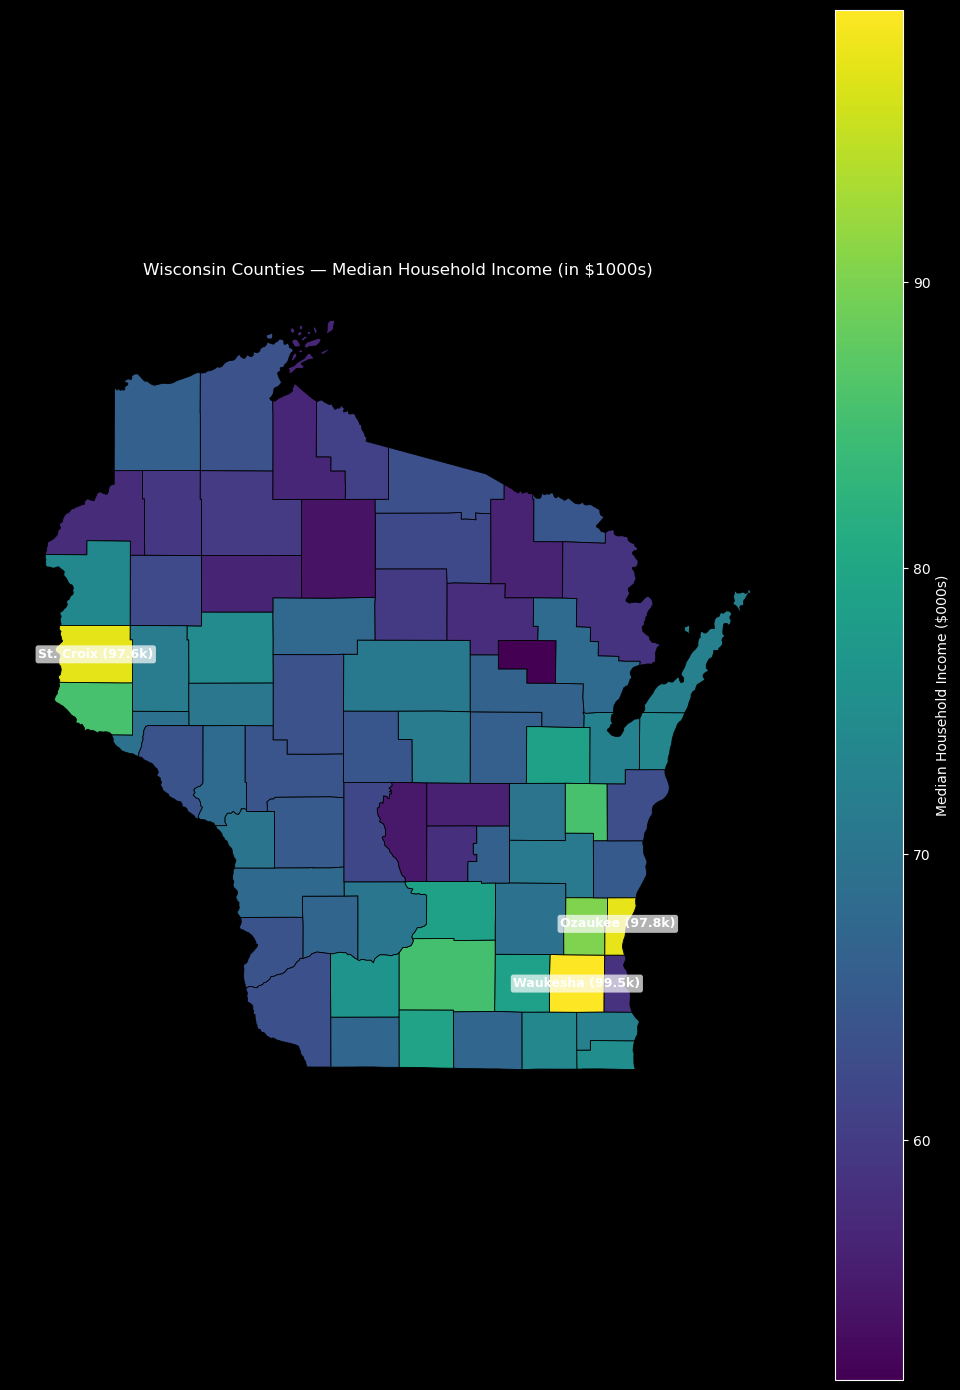

In [27]:
merged['Median_HHI_k'] = merged['Median_HHI'] / 1000.0

fig, ax = plt.subplots(figsize=(10, 14))
merged.plot(
    column='Median_HHI_k',
    cmap='viridis',
    linewidth=0.6,
    edgecolor='black',
    legend=True,
    legend_kwds={'label': 'Median Household Income ($000s)'},
    ax=ax
)

name_col = 'NAME' if 'NAME' in merged.columns else ('NAMELSAD' if 'NAMELSAD' in merged.columns else 'FipsCode')
top3 = merged.nlargest(3, 'Median_HHI_k').copy()
centroids = top3.geometry.centroid

for (_, row), pt in zip(top3.iterrows(), centroids):
    label = f"{row[name_col]} ({row['Median_HHI_k']:.1f}k)"
    ax.text(pt.x, pt.y, label, fontsize=9, fontweight='bold', ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.7)) # Used online resources to make centroids nicer and add box around text

ax.set_title("Wisconsin Counties — Median Household Income (in $1000s)")
ax.axis('off')
plt.tight_layout()
plt.show()

In [28]:
print("hello Alejandro or Professor Swanson :)")

hello Alejandro or Professor Swanson :)
